<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


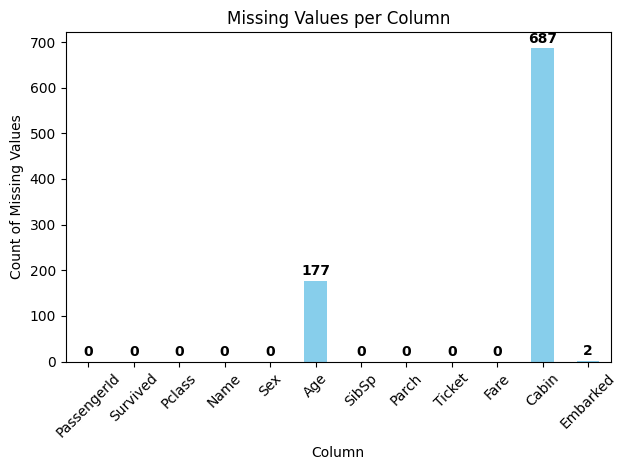

Survival Counts:
 Survived
0    549
1    342
Name: count, dtype: int64


C:\Users\aroma\AppData\Local\Temp\ipykernel_10552\4257294736.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Survived', data=df, palette='pastel')


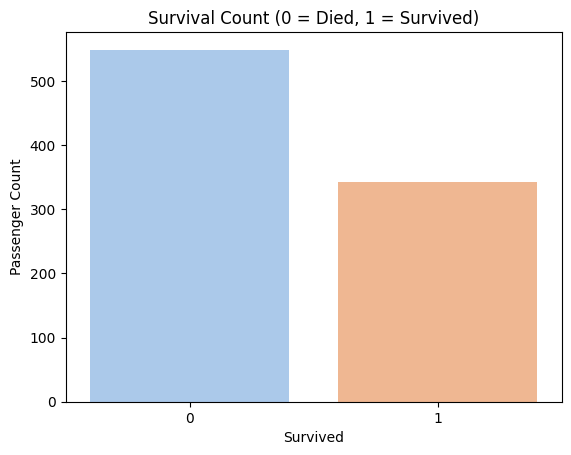


Gender Counts:
 Sex
male      577
female    314
Name: count, dtype: int64

Survival by Gender:
 Sex     Survived
female  0            81
        1           233
male    0           468
        1           109
dtype: int64


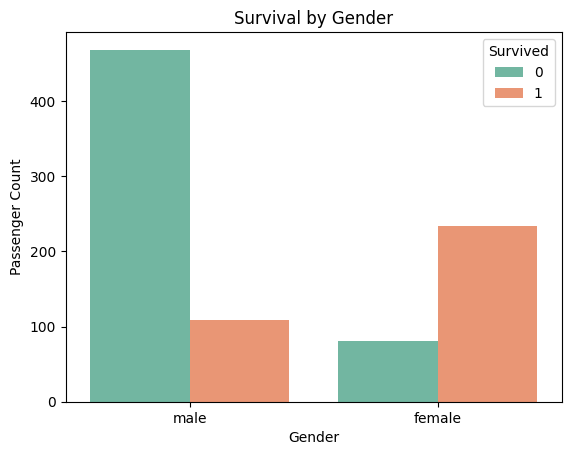


Passenger Class Counts:
 Pclass
3    491
1    216
2    184
Name: count, dtype: int64


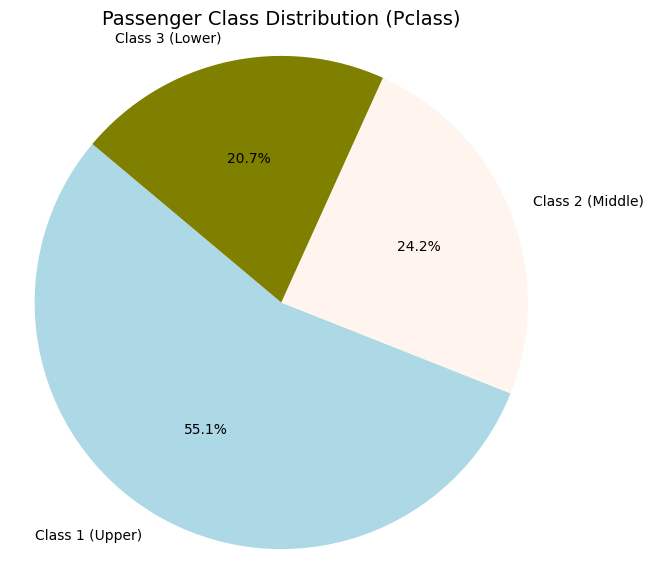

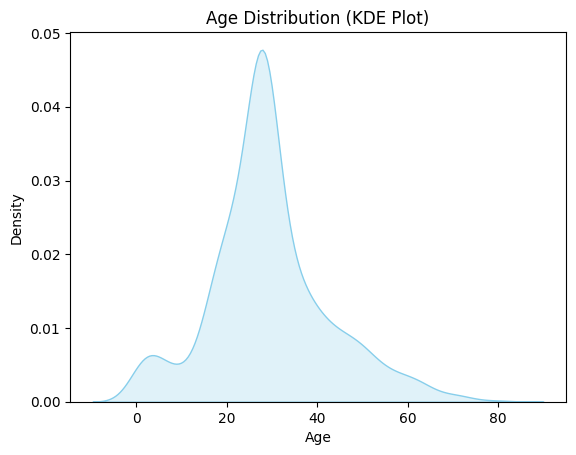

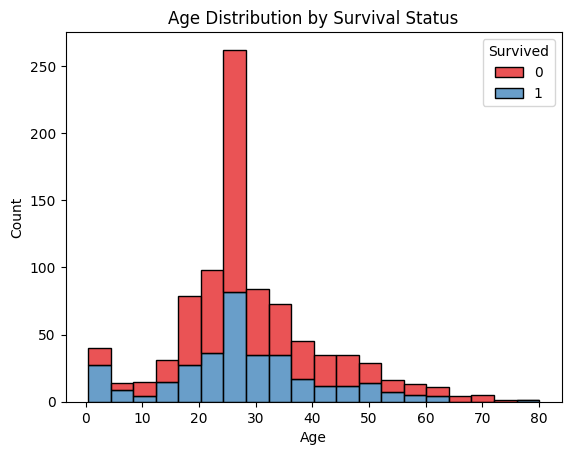

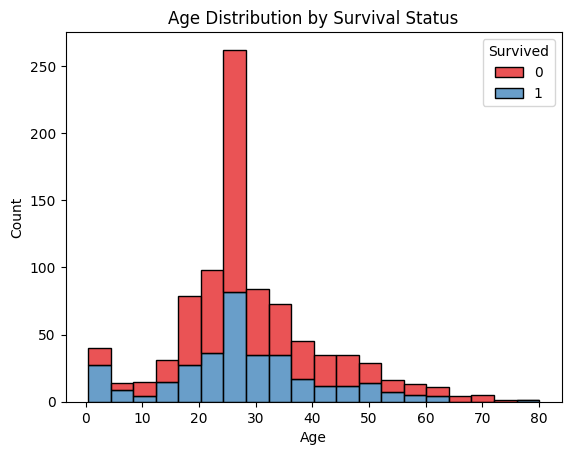

In [26]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
file_path = "C:/Users/aroma/Desktop/titanic.csv"
df = pd.read_csv(file_path)
df.head()
df.shape
df.info()
df.duplicated().value_counts()
print(df.isnull().sum())
missing = df.isnull().sum()
ax = missing.plot(kind='bar', color='skyblue')
plt.title('Missing Values per Column')
plt.ylabel('Count of Missing Values')
plt.xlabel('Column')
plt.xticks(rotation=45)
for index, value in enumerate(missing):
    plt.text(index, value + 5, str(value), ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()
df = df.drop(columns=['Cabin'])
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])


    # 1 survival cound bar

survival_counts = df['Survived'].value_counts()

print("Survival Counts:\n", survival_counts)
sns.countplot(x='Survived', data=df, palette='pastel')
plt.title('Survival Count (0 = Died, 1 = Survived)')
plt.xlabel('Survived')
plt.ylabel('Passenger Count')
plt.show()


    # 2 SURVIVAL BY GENDER


gender_counts = df['Sex'].value_counts()
print("\nGender Counts:\n", gender_counts)

  # Count of survived grouped by gender

survival_by_gender = df.groupby(['Sex', 'Survived']).size()
print("\nSurvival by Gender:\n", survival_by_gender)
sns.countplot(x='Sex', hue='Survived', data=df, palette='Set2')
plt.title('Survival by Gender')
plt.xlabel('Gender')
plt.ylabel('Passenger Count')
plt.legend(title='Survived')
plt.show()

  #passenger class distribution

# Count of passengers by class
pclass_counts = df['Pclass'].value_counts()
print("\nPassenger Class Counts:\n", pclass_counts)
labels = ['Class 1 (Upper)', 'Class 2 (Middle)', 'Class 3 (Lower)']

# pie chart
plt.figure(figsize=(7, 7))
plt.pie(pclass_counts, labels=labels, autopct='%1.1f%%', startangle=140, colors=['lightblue', 'seashell', 'olive'])
plt.title('Passenger Class Distribution (Pclass)', fontsize=14)
plt.axis('equal')  # Ensures it's a circle
plt.show()


  # AGE DISTRIBUTION

sns.kdeplot(df['Age'], fill=True, color='skyblue')
plt.title('Age Distribution (KDE Plot)')
plt.xlabel('Age')
plt.ylabel('Density')
plt.show()


 # AGE AND SURVIVAL

sns.histplot(data=df, x='Age', hue='Survived', multiple='stack', bins=20, palette='Set1')
plt.title('Age Distribution by Survival Status')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()


# SURVIVAL BY AGE GROUP

sns.histplot(data=df, x='Age', hue='Survived', multiple='stack', bins=20, palette='Set1')
plt.title('Age Distribution by Survival Status')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()